# Detecting Structural Distress at Scale
### A Geospatial Foundation Model Approach to Urban Building Safety

**Course:** MUSA 6500 – Geospatial Machine Learning in Remote Sensing  
**Authors:** Jason Fan, Henry Sywulak-Herr

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Environment setup & imports |
| 2 | Data loading (imagery, footprints, labels, elevation) |

---
## 1. Environment Setup

In [20]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\Jason Fan\AppData\Roaming\uv\python\cpython-3.11.14-windows-x86_64-none\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "f:\GitHub\musa6500-finalproject\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "f:\GitHub\musa6500-finalproject\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Jason Fan\AppData\Roaming\uv\python\cpython-3.11.14-windows-x86_64-none\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import show as rshow

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Add project root to path so loader scripts are importable ──────────────
PROJECT_ROOT = Path('.').resolve()   # adjust if notebook is in a sub-folder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Device: cpu
Project root: F:\GitHub\musa6500-finalproject


---
## 2. Data Loading

Each dataset is loaded via its own dedicated module.  

### Imagery

In [22]:
from load_imagery import open_imagery

# This creates a lazy DataArray backed by the remote Cloud Optimized GeoTIFF (COG)
src = open_imagery()

[load_imagery] Opened: https://musa-650.s3.amazonaws.com/phl_aerial_0.3m.tif
  CRS   : EPSG:2272
  Shape : (3, 123383, 109972)  (bands Ã— rows Ã— cols)
  Res   : (0.984252, -0.984252) (x_res, y_res)


### Parcels & Permits

In [2]:
from load_building_footprints import load_building_footprints, fetch_geojson
from pathlib import Path

VECTOR_DIR = Path('data/vector')
CRS = 'EPSG:2272'

# PWD parcels (primary geometry for all spatial joins)
parcels = load_building_footprints()
print(f'Parcels: {len(parcels):,}')

# eCLIPSE permits – used to filter false positives (new construction)
PERMIT_URL = 'https://hub.arcgis.com/api/v3/datasets/8d18914ff740444793937d8724c64da8_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1'
permits = fetch_geojson('permits', PERMIT_URL, VECTOR_DIR).to_crs(CRS)
print(f'Permits: {len(permits):,}')

[load_building_footprints] Fetching parcels from https://opendata.arcgis.com/datasets/84baed491de44f539889f2af178ad85c_0.geojson ...
  → cached to data\vector\parcels.geojson
[load_building_footprints] Parcels loaded: 547,290 | CRS: EPSG:2272
Parcels: 547,290
[load_building_footprints] Fetching permits from https://hub.arcgis.com/api/v3/datasets/8d18914ff740444793937d8724c64da8_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1 ...
  → cached to data\vector\permits.geojson
Permits: 13,902


### Training Labels (L&I Violations)

Fetching imm_dang...
[load_labels] Fetching imm_dang from Carto API...
  → cached to data\labels\imm_dang.geojson
  rows: 139
Fetching unsafe...
[load_labels] Fetching unsafe from Carto API...
  → cached to data\labels\unsafe.geojson
  rows: 2,629
Fetching clean_seal...
[load_labels] Fetching clean_seal from Carto API...
  → cached to data\labels\clean_seal.geojson
  rows: 8,564
Labeled Imminently Dangerous : 136
Labeled Unsafe               : 7,794
Labeled Stable               : 539,360


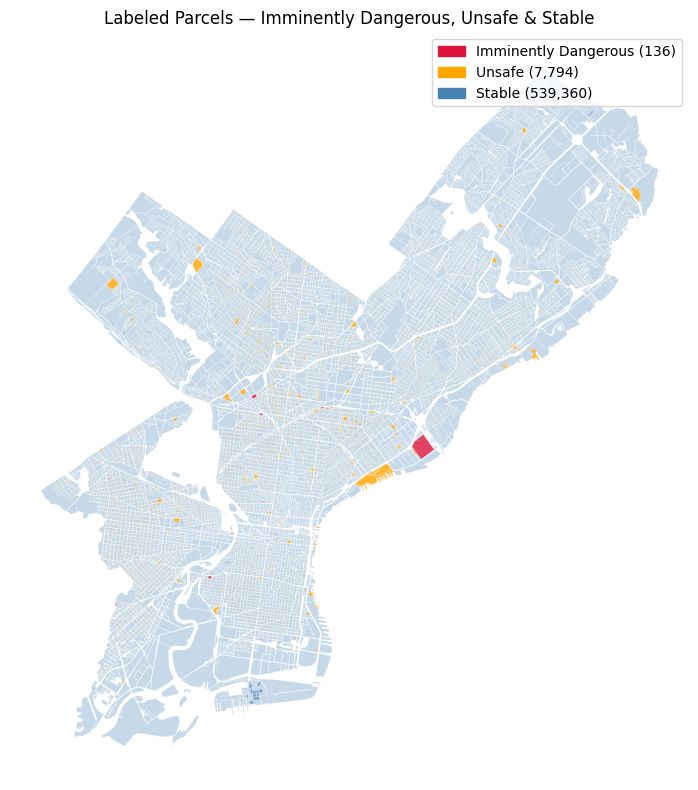

In [10]:
import importlib
import load_labels
importlib.reload(load_labels)

from load_labels import load_labels, plot_labels

parcels_labeled = load_labels(parcels, permits=permits)

plot_labels(parcels_labeled)

Labeled Imminently Dangerous : 136
Labeled Unsafe               : 7,794
Labeled Stable               : 539,360

"Imminently dangerous" is too small of a sample for the deep learning model to learn distinct classes. Will be merging unsafe and ID into a single "distressed" class. 

### Create balanced df

In [12]:
import pandas as pd

# 1. Isolate all the minority class parcels (Unsafe and Imminently Dangerous)
distressed_parcels = parcels_labeled[parcels_labeled['label'].isin([1, 2])].copy()

# 2. Randomly sample the "Stable" (0) class. 
# Let's take twice as many Stable as Distressed (a 2:1 ratio is a good starting point)
num_distressed = len(distressed_parcels)
num_stable_to_keep = num_distressed * 2

print(f"Keeping {num_distressed} distressed parcels and {num_stable_to_keep} stable parcels.")

# Sample from the stable parcels
stable_parcels = parcels_labeled[parcels_labeled['label'] == 0].sample(
    n=num_stable_to_keep, 
    random_state=42 # Set random state for reproducibility
).copy()

# 3. Combine them and shuffle the dataset
balanced_parcels = pd.concat([distressed_parcels, stable_parcels])
balanced_parcels = balanced_parcels.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nNew Balanced Label Counts:")
print(balanced_parcels['label'].value_counts())

Keeping 7930 distressed parcels and 15860 stable parcels.

New Balanced Label Counts:
label
0    15860
1     7794
2      136
Name: count, dtype: int64


Label merge

In [23]:
# Map Imminently Dangerous (2) to Unsafe/Distressed (1)
balanced_parcels['label'] = balanced_parcels['label'].replace({2: 1})

print("Final Binary Label Counts (0=Stable, 1=Distressed):")
print(balanced_parcels['label'].value_counts())

Final Binary Label Counts (0=Stable, 1=Distressed):
label
0    15860
1     7930
Name: count, dtype: int64


### Focal Loss:

weighted cross entropy is the standard fix but focal loss is better for is our model struggles to recognize the visual signs of decay. 

In [13]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: raw predictions from your model (logits)
        # targets: actual labels (0, 1, or 2)
        
        # Calculate standard cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # pt is the probability the model assigned to the CORRECT class
        pt = torch.exp(-ce_loss) 
        
        # Calculate Focal Loss
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Initialize it to use in your training loop
criterion = FocalLoss(gamma=2.0)

### Image augmentation 
this helps oversample the distressed buildings 

In [24]:
import torchvision.transforms as T

# Standard size for most vision foundation models
IMAGE_SIZE = (224, 224) 

train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(IMAGE_SIZE), # Force consistent size
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=(0, 360)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
])

# Validation transforms should NEVER have random augmentations
val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(IMAGE_SIZE),
    T.ToTensor(),
])

pytorch dataset class

In [25]:
# --- Create a new cell for the Dataset Class ---
from load_imagery import read_parcel_chip

class ParcelDataset(Dataset):
    def __init__(self, gdf, imagery_src, transform=None):
        # Reset index to ensure iloc works cleanly
        self.gdf = gdf.reset_index(drop=True)
        self.src = imagery_src
        self.transform = transform

    def __len__(self):
        return len(self.gdf)

    def __getitem__(self, idx):
        row = self.gdf.iloc[idx]
        geom = row.geometry
        label = row.label

        try:
            # Clip imagery to this specific parcel
            chip = read_parcel_chip(self.src, geom)
            
            # Extract RGB bands and reshape for PIL (H, W, C)
            # Assuming bands 0, 1, 2 are RGB. 
            img_data = chip.values[:3, :, :].transpose(1, 2, 0)
            
        except Exception as e:
            # If a parcel falls outside the imagery bounds or fails to clip,
            # return a blank image to keep the batch from crashing.
            img_data = np.zeros((224, 224, 3), dtype=np.uint8)

        if self.transform:
            img_tensor = self.transform(img_data)
            
        return img_tensor, torch.tensor(label, dtype=torch.long)

Helper function:

In [29]:
from torch.utils.data import DataLoader

def create_dataloaders(train_gdf, val_gdf, src, train_tfm, val_tfm, batch_size=32):
    """Creates and returns a dictionary of train and val dataloaders."""
    datasets = {
        'train': ParcelDataset(train_gdf, src, transform=train_tfm),
        'val': ParcelDataset(val_gdf, src, transform=val_tfm)
    }
    loaders = {
        'train': DataLoader(datasets['train'], batch_size=batch_size, shuffle=True, drop_last=True),
        'val': DataLoader(datasets['val'], batch_size=batch_size, shuffle=False)
    }
    return loaders

train/validation split

In [26]:
# --- Create a new cell for DataLoaders ---
from sklearn.model_selection import train_test_split

# Split the data (80% Train, 20% Validation)
# stratify=True ensures the 2:1 ratio is preserved in both sets
train_gdf, val_gdf = train_test_split(
    balanced_parcels, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=balanced_parcels['label']
)

print(f"Training parcels: {len(train_gdf)}")
print(f"Validation parcels: {len(val_gdf)}")

# Instantiate Datasets
train_dataset = ParcelDataset(train_gdf, src, transform=train_transforms)
val_dataset = ParcelDataset(val_gdf, src, transform=val_transforms)

# Create DataLoaders (Batches)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Quick test to make sure the pipeline works
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch label shape: {labels.shape}") # Should be [32]

Training parcels: 19032
Validation parcels: 4758
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


### Build parceldataset class

In [27]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from load_imagery import read_parcel_chip
import torchvision.transforms as T

# 1. REMAP LABELS (Binary Classification: 0=Stable, 1=Distressed)
# Run this once on your balanced dataframe
balanced_parcels['label'] = balanced_parcels['label'].replace({2: 1})
print("Binary Label Counts:")
print(balanced_parcels['label'].value_counts())

# 2. DEFINE TRANSFORMS
IMAGE_SIZE = (224, 224) 

train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(IMAGE_SIZE), # Force consistent square size for the model
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=(0, 360)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
])

val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(IMAGE_SIZE),
    T.ToTensor(),
])

# 3. BUILD THE DATASET CLASS
class ParcelDataset(Dataset):
    def __init__(self, gdf, imagery_src, transform=None):
        self.gdf = gdf.reset_index(drop=True)
        self.src = imagery_src
        self.transform = transform

    def __len__(self):
        return len(self.gdf)

    def __getitem__(self, idx):
        row = self.gdf.iloc[idx]
        geom = row.geometry
        label = row.label

        try:
            # Clip imagery to this specific parcel footprint
            chip = read_parcel_chip(self.src, geom)
            
            # Extract RGB bands (assuming first 3 bands) and reshape for PIL
            img_data = chip.values[:3, :, :].transpose(1, 2, 0)
            
        except Exception as e:
            # Fallback: if clipping fails (e.g., parcel outside imagery bounds), return a black square
            img_data = np.zeros((224, 224, 3), dtype=np.uint8)

        if self.transform:
            img_tensor = self.transform(img_data)
            
        return img_tensor, torch.tensor(label, dtype=torch.long)

Binary Label Counts:
label
0    15860
1     7930
Name: count, dtype: int64


Split data and create batches

In [28]:
from sklearn.model_selection import train_test_split

# Split the data (80% Train, 20% Validation)
train_gdf, val_gdf = train_test_split(
    balanced_parcels, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=balanced_parcels['label']
)

# Instantiate Datasets
train_dataset = ParcelDataset(train_gdf, src, transform=train_transforms)
val_dataset = ParcelDataset(val_gdf, src, transform=val_transforms)

# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test it! This will trigger the lazy loading and clipping for one batch
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch label shape: {labels.shape}") # Should be [32]

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
